In [1]:
import numpy as np
from tensorflow.keras.models import load_model
import hls4ml
from qkeras.utils import _add_supported_quantized_objects

2026-05-28 12:36:12.036645: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-28 12:36:12.075428: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Matplotlib created a temporary config/cache directory at /tmp/matplotlib-nfao_bxn because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support 

/opt/conda/lib/python3.10/site-packages/hls4ml/converters/__init__.py:27: UserWarning: WARNING: Pytorch converter is not enabled!
  warnings.warn("WARNING: Pytorch converter is not enabled!", stacklevel=1)


In [2]:
resolution = 150

#model_orig = load_model(f'unpruned_model_{resolution}.h5')
co = {}
_add_supported_quantized_objects(co)
X_total = np.load(f"../Data/X_Data_Bank_{resolution}.npy")
Y_total = np.load(f"../Data/Y_Data_Bank_{resolution}.npy")
X_test = X_total[1500:2000,:,:]
Y_test = Y_total[1500:2000,:,:]
NUM_EVENTS = 500
TIME_STEPS = int(12000/resolution)
base_name ="no_opt_150_"
filters = [1,2,4,8,16,32,64]
successive_name = ""
names = [f"{base_name}{i}{successive_name}" for i in filters]

In [3]:
y_predictions = []
Y_test_reduced = Y_test
for i in range(NUM_EVENTS):
    for j in range(TIME_STEPS):
        if Y_test_reduced[i][j]!=0:
            Y_test_reduced[i][j]=1
            
for i in range(len(filters)):
    newModel = load_model(f"../Models/quantized_model_{names[i]}.h5", custom_objects=co)
    new_y_predict = newModel.predict(X_test)
    y_predictions.append(new_y_predict)

2026-05-28 12:36:13.983340: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089
/opt/conda/lib/python3.10/site-packages/keras/initializers/initializers_v2.py:120: UserWarning: The initializer HeNormal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


16/16 [==============================] - 0s 2ms/step


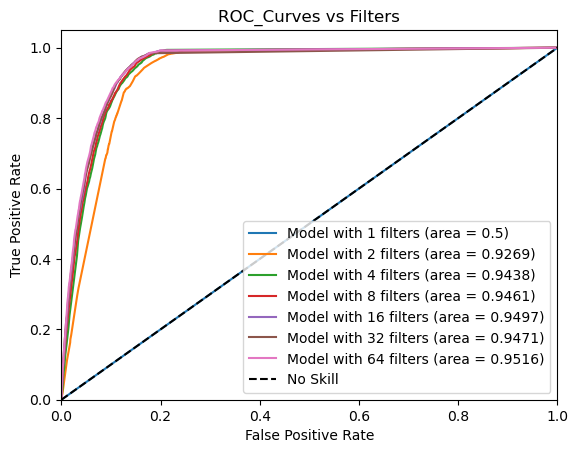

In [4]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
def plotROC_Comparison(y_test_reduced, listYs, filters):
    plt.figure()  
    for Y_predict_index in range(len(listYs)):
        Y_predict = listYs[Y_predict_index]
        fpr, tpr, thresholds = roc_curve(Y_test_reduced.flatten(), Y_predict.flatten()) 
        roc_auc = auc(fpr, tpr)
        roc_auc = int(roc_auc * 10000) / 10000
        plt.plot(fpr, tpr, label=f'Model with {filters[Y_predict_index]} filters (area = {roc_auc})')
    plt.title("ROC_Curves vs Filters")
    plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    #plt.savefig("ROC_Curve_Filters",pad_inches=0.1)
    plt.show()
        
#plotROC_Comparison(Y_test_reduced,y_predict_hls, y_predict_hls1, y_predict_final)
plotROC_Comparison(Y_test_reduced,y_predictions, filters)
def findROCVal(Y_test_reduced, Y_predict): 
    fpr, tpr, thresholds = roc_curve(Y_test_reduced.flatten(), Y_predict.flatten()) 
    roc_auc = auc(fpr, tpr)
    return roc_auc

In [5]:
def displayModel(index, X_data_ex, y_data_ex, name):
    fig, ax1 = plt.subplots()
    ax1.set_xlabel("time (~ns)")
    ax1.set_ylabel('Simulated Signal', color = 'tab:blue') 
    ax1.set_ylim(-5,30)
    ax1.plot(np.arange(0.0, TIME_STEPS * 0.2, 0.2),X_data_ex[index,:], "C0-")
    
    ax2 = ax1.twinx()
    ax2.set_ylabel("Model Pulse Location and Amplitude", color = 'tab:orange')
    ax2.set_ylim(-0.4,2.4)
    plt.plot(np.arange(0.0, TIME_STEPS * 0.2, 0.2),y_data_ex[index,:], "C1-", label = "Desired Output")
    plt.title("Model Predictions")
    plt.savefig(name, pad_inches=0.1)
    plt.show()
def analyzePrecisions(model_test,X_test, Y_test_reduced, testingPrecisions):
    n = len(testingPrecisions)
    resultAUC = []
    for i in range(n):
        hls_config = hls4ml.utils.config_from_keras_model(
            model_test,
            granularity='name',
            backend='Vivado',
            default_precision=f'ap_fixed{testingPrecisions[i]}'
        )
        hls_model = hls4ml.converters.convert_from_keras_model(
            model_final,
            hls_config=hls_config,
            backend='Vivado',
            output_dir=f'../HLS_models/{model_test}{testingPrecisions[i]}',
            part='xcu250-figd2104-2L-e',
            io_type='io_stream',
        )
        hls_model.compile()
        y_predict_hls = hls_model.predict(X_test)
        ROCcurve = findROCVal(Y_test_reduced, y_predict_hls)
        resultAUC.append(ROCcurve)
    plt.plot([i for i in range(n)],resultAUC)
testingPrecisions = ["<10,4>","<12,6>","<14,8>","<16,10>","<18,12>","<20,14>","<22,16>"]
analyzePrecisions(model_final,X_test,Y_test_reduced, testingPrecisions)
        

NameError: name 'model_final' is not defined

#### 

In [ ]:




displayModel(5,X_test,Y_test, "OriginalPulse.png")
displayModel(5,X_test,y_predict_final, "OriginalPulse.png")


In [ ]:
testingPrecisions = ["<10,8>","<12,8>","<14,8>","<16,8>","<18,8>","<20,8>","<22,8>"]
analyzePrecisions(model_final,X_test,Y_test_reduced, testingPrecisions)

In [ ]:
print(hls_model1.trace(X_test))
print(model_orig.predict(X_test))

In [ ]:
from tensorflow.keras.models import Model
import numpy as np

# Get outputs of all layers
layer_outputs = [layer.output for layer in model_final.layers]

debug_model = Model(
    inputs=model_final.input,
    outputs=layer_outputs
)

# Run inference
tf_outputs = debug_model.predict(X_test)

# Save
np.savez_compressed(
    "tf_outputs.npz",
    **{
        layer.name: output
        for layer, output in zip(model_final.layers, tf_outputs)
    }
)

predictions, trace = hls_model1.trace(X_test)
np.savez_compressed(
    "hls_trace.npz",
    **trace
)

In [ ]:
tf_data = np.load("tf_outputs.npz")
hls_data = np.load("hls_trace.npz")
print(hls_data.files,tf_data.files)

In [ ]:
for name in hls_data.files:

    if name in tf_data.files:

        tf_out = tf_data[name]
        hls_out = hls_data[name]

        mae = np.mean(np.abs(tf_out - hls_out))
        max_err = np.max(np.abs(tf_out - hls_out))

        print(f"{name}")
        print(f"  MAE     : {mae}")
        print(f"  Max Err : {max_err}")